In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
num_classes = 10
input_shape = (32,32,3) # Corrected to CIFAR-10 dimensions
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

# X_train and X_test are already numpy arrays and in the correct shape (num_samples, 32, 32, 3).
# Therefore, the following reshape and type conversion checks are not needed for CIFAR-10.
# If you intend to resize or convert to grayscale, dedicated preprocessing steps are required.
# For now, we assume the intention is to use the original CIFAR-10 dimensions.

print(X_train.shape)
print(X_test.shape)

print('Number of classes:',len(np.unique(y_train)))
print('Classes:',np.unique(y_train))
print(y_train[:5])

(50000, 32, 32, 3)
(10000, 32, 32, 3)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
[[6]
 [9]
 [9]
 [4]
 [1]]


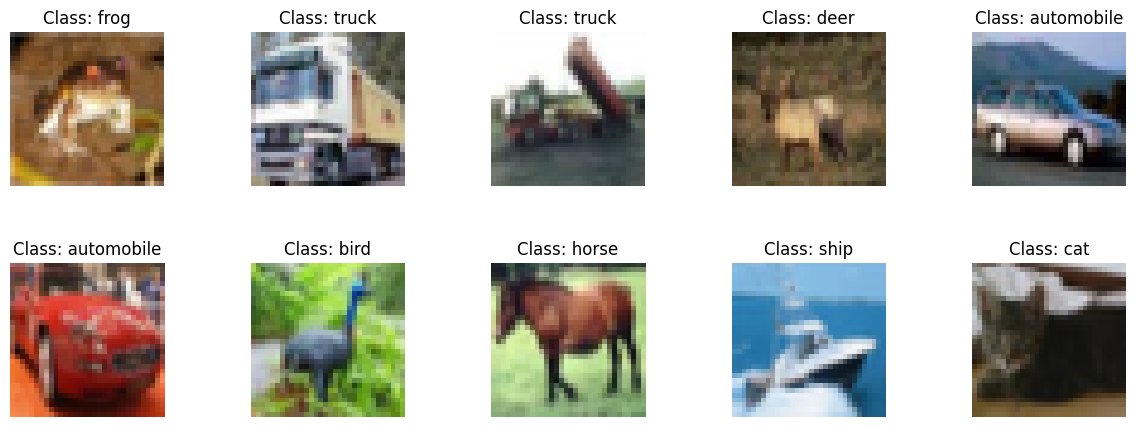

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    # Hiển thị ảnh (32x32x3)
    ax[i].imshow(X_train[i])
    # Sử dụng .item() để lấy giá trị số từ mảng một cách an toàn
    label_index = int(y_train[i].item())
    ax[i].title.set_text(f'Class: {class_names[label_index]}')
    ax[i].axis('off')
plt.subplots_adjust(hspace = 0.5)
plt.show()

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


In [ ]:
from keras.layers import BatchNormalization, Dropout

model = Sequential()
model.add(Input(shape=input_shape))

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

# Block 3
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.4158 - loss: 1.7400 - val_accuracy: 0.1914 - val_loss: 3.0296
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 351s 997ms/step - accuracy: 0.5900 - loss: 1.1535 - val_accuracy: 0.6248 - val_loss: 1.0690
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 345s 980ms/step - accuracy: 0.6596 - loss: 0.9712 - val_accuracy: 0.7050 - val_loss: 0.8342
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 344s 978ms/step - accuracy: 0.7070 - loss: 0.8434 - val_accuracy: 0.7202 - val_loss: 0.8066
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 385s 987ms/step - accuracy: 0.7354 - loss: 0.7592 - val_accuracy: 0.7644 - val_loss: 0.6815
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 345s 982ms/step - accuracy: 0.7556 - loss: 0.7047 - val_accuracy: 0.7582 - val_loss: 0.6999
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 341s 968ms/step - accuracy: 0.7753 - loss: 0.6491 - val_accuracy: 0.7608 - val_loss: 0.7187
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 346s 982ms/step - accuracy: 0.7892 - lo

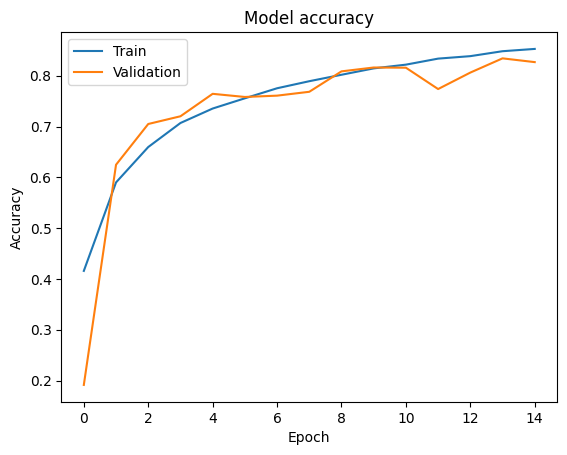

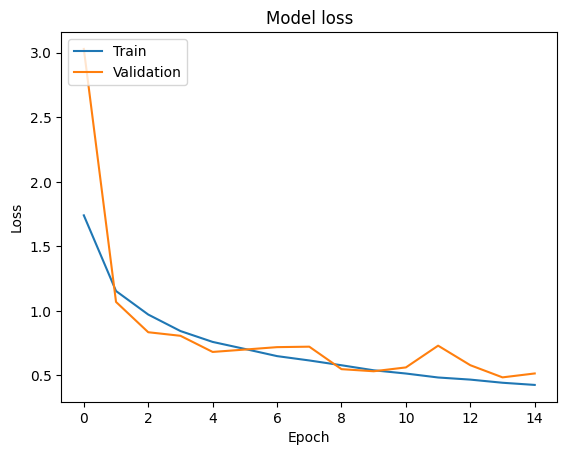

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, verbose = 2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 19s - 59ms/step - accuracy: 0.8158 - loss: 0.5519
Test loss: 0.5518847107887268
Test accuracy: 0.8158000111579895


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
Dự đoán: cat
Thực tế: cat


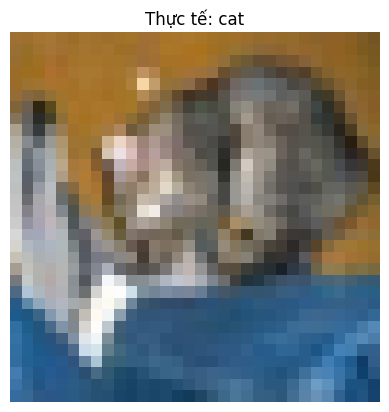

In [ ]:
predict = model.predict(X_test[:1])
# Lấy chỉ số lớp có xác suất cao nhất
predicted_idx = np.argmax(predict)
actual_idx = np.argmax(y_test[0])

print(f'Dự đoán: {class_names[predicted_idx]}')
print(f'Thực tế: {class_names[actual_idx]}')

# Sửa lỗi: Sử dụng X_test[0] thay vì X_test[:0]
plt.imshow(X_test[0])
plt.title(f'Thực tế: {class_names[actual_idx]}')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


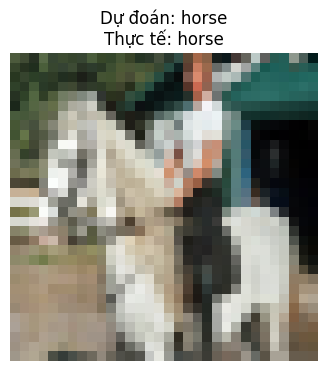

Chi tiết xác suất cho từng lớp:
airplane    : 0.0000
automobile  : 0.0000
bird        : 0.0002
cat         : 0.0007
deer        : 0.0016
dog         : 0.0038
frog        : 0.0000
horse       : 0.9937
ship        : 0.0000
truck       : 0.0000


In [ ]:
# Thay đổi số này để thử các hình ảnh khác (từ 0 đến 9999)
index_to_test = 56

# Dự đoán
img = X_test[index_to_test]
img_tensor = np.expand_dims(img, axis=0)
prediction = model.predict(img_tensor)

predicted_class = class_names[np.argmax(prediction)]
actual_class = class_names[np.argmax(y_test[index_to_test])]

# Hiển thị kết quả
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f'Dự đoán: {predicted_class}\nThực tế: {actual_class}')
plt.axis('off')
plt.show()

# In ra bảng xác suất chi tiết
print("Chi tiết xác suất cho từng lớp:")
for name, prob in zip(class_names, prediction[0]):
    print(f"{name:12}: {prob:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step
Tổng số ảnh dự đoán sai: 1842/10000


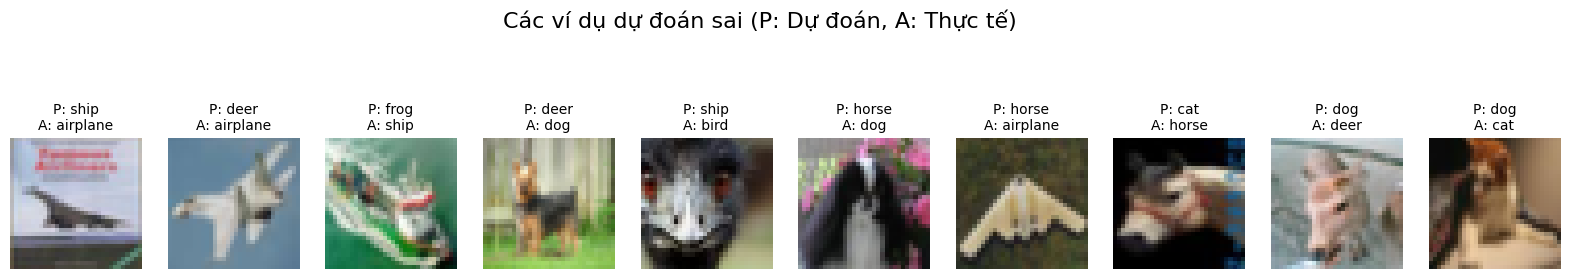

In [ ]:
# Lấy dự đoán cho toàn bộ tập test (hoặc một phần để nhanh hơn)
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
actual_labels = np.argmax(y_test, axis=1)

# Tìm các chỉ số mà dự đoán khác với thực tế
misclassified_indices = np.where(predicted_labels != actual_labels)[0]

print(f"Tổng số ảnh dự đoán sai: {len(misclassified_indices)}/{len(X_test)}")

# Hiển thị 10 hình ảnh dự đoán sai đầu tiên
plt.figure(figsize=(20, 4))
for i, idx in enumerate(misclassified_indices[:10]):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[idx])
    plt.title(f"P: {class_names[predicted_labels[idx]]}\nA: {class_names[actual_labels[idx]]}", fontsize=10)
    plt.axis('off')
plt.suptitle("Các ví dụ dự đoán sai (P: Dự đoán, A: Thực tế)", fontsize=16)
plt.show()